# Overview of anomalies

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from autoencoders.ae import AutoEncoder
from anomaly.metrics import Reconstruction


from sdss.metadata import MetaData

meta = MetaData()

2026-01-15 19:23:03.325808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Constants

In [3]:
mse_cols = ['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97']
mse_rel_cols = ['mse_rel', 'mse_filter_250_rel', 'mse_97_rel', 'mse_filter_250_97_rel']

In [4]:
mse_family = ['mse', 'mse_97', 'mse_filter_250', 'mse_filter_250_97']
chi_sq_family = ['mse_rel', 'mse_97_rel', 'mse_filter_250_rel', 'mse_filter_250_97_rel']

# Custom functions

# Config

## Directories

In [5]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_ids = [f"bin_{i:02d}" for i in range(4)]

## Data

In [6]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

In [22]:
bin_id = 'bin_03'
score_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

score_cols = mse_cols + mse_rel_cols
# rank_cols = mse_rank_cols + mse_rank_rel_cols

merged_03_df = score_03_df.join(
    final_meta_df[['z', 'snMedian']],
    how='inner'
).copy()

merged_03_df[score_cols] = merged_03_df[
    score_cols
] / merged_03_df[score_cols].max()
# -----------
n_spec = score_03_df.shape[0]
n_top_1_pct = int(n_spec*0.01)
n_top_1_pct

1818

In [10]:
rank = np.arange(score_03_df.shape[0]).astype(int)
score_03_rank_df = score_03_df.copy()

cols_dtypes_dict = {}

for col in score_03_df.columns:

    index_sorted = score_03_df.sort_values(
        by=col, ascending=False
    ).index

    rank_col = f'rank_{col}'
    
    cols_dtypes_dict[rank_col] = 'int'
    cols_dtypes_dict[col] = 'float'

    score_03_rank_df.loc[index_sorted, f'rank_{col}'] = rank

In [11]:
score_03_rank_df = score_03_rank_df.astype(cols_dtypes_dict)

In [21]:
bin_id = 'bin_02'
score_02_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

score_cols = mse_cols + mse_rel_cols
# rank_cols = mse_rank_cols + mse_rank_rel_cols

merged_02_df = score_02_df.join(
    final_meta_df[['z', 'snMedian']],
    how='inner'
).copy()

merged_02_df[score_cols] = merged_02_df[
    score_cols
] / merged_02_df[score_cols].max()

## Model

In [8]:
ae_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/bin_03/winner",
)

ae_02 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/bin_02/winner_0021",
)

In [12]:
ae_03.get_architecture_and_model_str()

['256_128_64_12_64_128_256', 'infoVae_rec_3776_alpha_0_lambda_9']

# Running Median Profile

In [59]:
merged_03_df.snMedian.describe()

count    181850.000000
mean         24.209400
std           6.719912
min          17.543710
25%          19.383460
50%          22.073380
75%          26.834085
max          92.638030
Name: snMedian, dtype: float64

In [33]:
merged_03_df.columns

Index(['mse_rel', 'mse_filter_250_97_rel', 'mse_95', 'mse_97_rel', 'mse',
       'mse_97', 'mse_filter_250_95_rel', 'mse_filter_300_95', 'mse_95_rel',
       'mse_filter_300', 'mse_filter_250_97', 'mse_filter_300_95_rel',
       'mse_filter_250', 'mse_filter_300_97', 'mse_filter_250_95',
       'mse_filter_300_97_rel', 'mse_filter_300_rel', 'mse_filter_250_rel',
       'z', 'snMedian'],
      dtype='object')

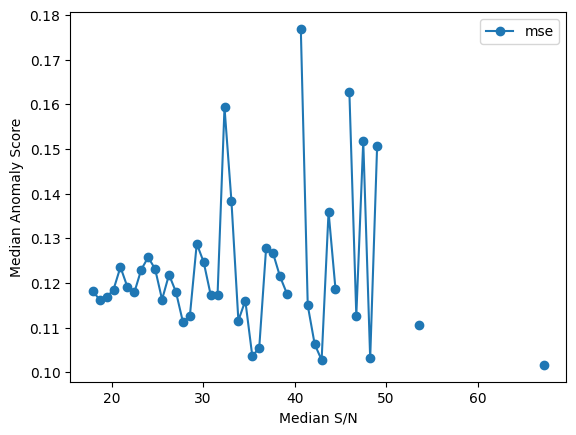

In [60]:
from scipy.stats import binned_statistic

df = merged_03_df.copy()

sn_min = df.snMedian.min()
sn_max = df.snMedian.max()

# metric = 'mse_filter_250'
# metric = 'mse_97'
# metric = 'mse_filter_250_97'
metric = 'mse'

top1_mask = df[metric] > df[metric].quantile(0.99)

df = df.loc[top1_mask]

n_bins = 100

bin_edges = np.linspace(sn_min, sn_max, n_bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate median score in each S/N bin
median_se, _, _ = binned_statistic(
    df['snMedian'],
    df[metric],
    statistic='median', bins=bin_edges
)

# Plot
plt.plot(bin_centers, median_se, label=metric, marker='o')
plt.xlabel("Median S/N")
plt.ylabel("Median Anomaly Score")
plt.legend()

In [57]:
top1_mask.sum()

1819

# Test scores

## Data

'http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=637325355518027776&apid='

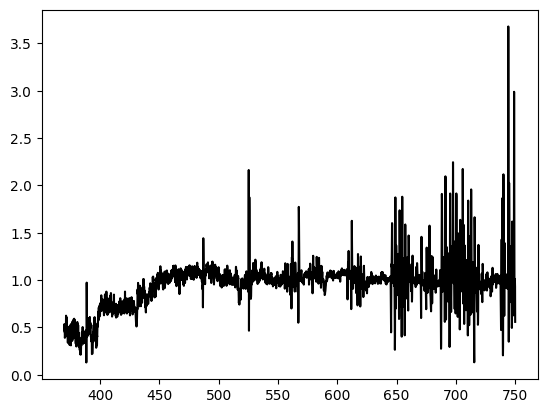

In [13]:
artifact_id = 637325355518027776
spec_idx = specobjid_to_idx(
        artifact_id, idx_id_spec
)
# ----------------------------------------------------
spec_artifact = spectra[spec_idx]
plt.plot(wave_nm, spec_artifact, color='black')
meta.get_sky_server_url(artifact_id)

'http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=1924292192684238848&apid='

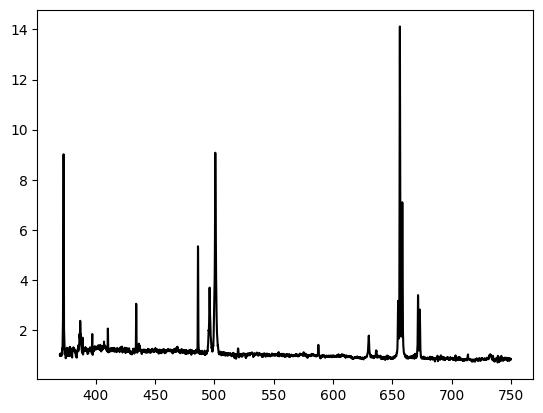

In [14]:
broad_id = 1924292192684238848
spec_idx = specobjid_to_idx(
        broad_id, idx_id_spec
)
# ----------------------------------------------------
spec_broad = spectra[spec_idx]
plt.plot(wave_nm, spec_broad, color='black')
meta.get_sky_server_url(broad_id)

In [15]:
score_03_df.mse.quantile(0.7)

2.6516001205733186

In [16]:
score_03_rank_df.loc[[artifact_id, broad_id], ['mse', 'rank_mse']]

,mse,rank_mse
specobjid,,
637325355518027776,10.488524,189
1924292192684238848,11.286596,153


In [17]:
score_03_df.loc[[artifact_id, broad_id]]

,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
specobjid,,,,,,,,
637325355518027776,10.488524,10.313478,5.903055,5.784308,10.231443,9.993050,6.219198,6.094217
1924292192684238848,11.286596,9.046563,3.457124,3.058767,6.260880,5.656998,3.213258,3.014451


# Artifact

In [18]:
rec_spec_artifact = ae_03.reconstruct(spec_artifact).reshape(-1)

# ----------------------------------------------------
mse_manual = np.sqrt(
        np.sum((spec_artifact - rec_spec_artifact)**2)
)
mse_module = Reconstruction(100, False).mse(
        spec_artifact, rec_spec_artifact
)[0][0]

print(f'mse_manual: {mse_manual:.4f}\tmse_module:{mse_module:.4f}')
# ----------------------------------------------------

mse_97_module = Reconstruction(97, False).mse(
        spec_artifact, rec_spec_artifact
)

mse_97_module

mse_manual: 10.4978	mse_module:10.4978


array([[5.93465942]])

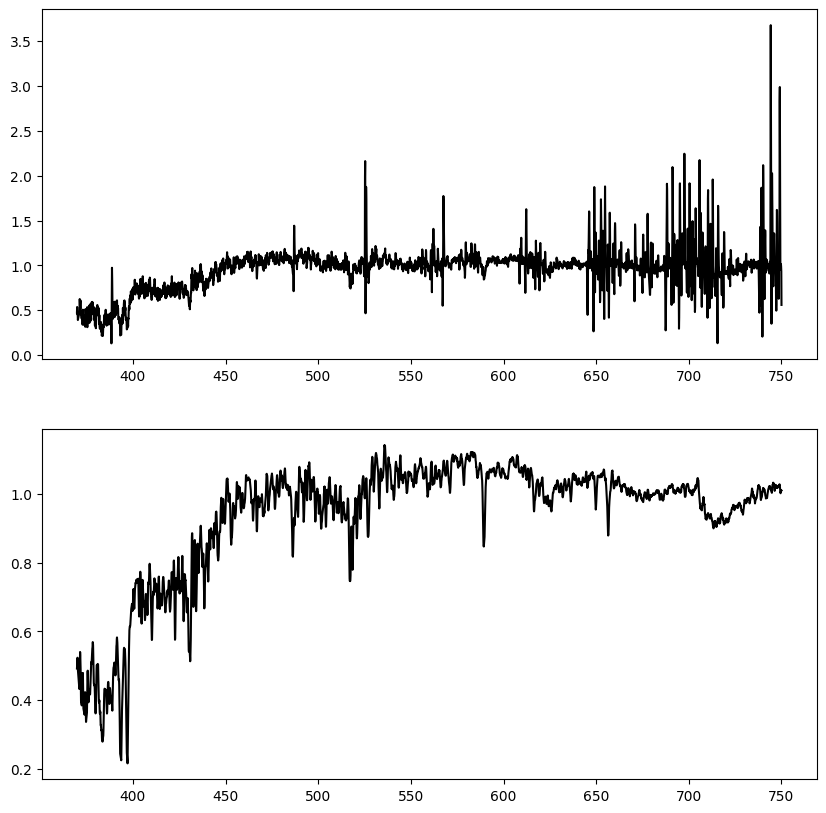

In [19]:
fig, ax = plt.subplots(2,1, figsize=(10, 10))


ax[0].plot(wave_nm, spec_artifact, color='black')
ax[1].plot(wave_nm, rec_spec_artifact, color='black')
plt.show()

# broad

In [20]:
rec_spec_broad = ae_03.reconstruct(spec_broad).reshape(-1)

# ----------------------------------------------------
mse_manual = np.sqrt(
        np.sum((spec_broad - rec_spec_broad)**2)
)
mse_module = Reconstruction().mse(
        spec_broad, rec_spec_broad
)[0][0]

print(f'mse_manual: {mse_manual:.4f}\tmse_module:{mse_module:.4f}')
# ----------------------------------------------------

mse_97_module = Reconstruction(97, False).mse(
        spec_broad, rec_spec_broad
)

mse_97_module

mse_manual: 11.3648	mse_module:11.3648


array([[3.43039873]])

In [21]:
score_03_df.loc[broad_id]

mse                      11.286596
mse_filter_250            9.046563
mse_97                    3.457124
mse_filter_250_97         3.058767
mse_rel                   6.260880
mse_filter_250_rel        5.656998
mse_97_rel                3.213258
mse_filter_250_97_rel     3.014451
Name: 1924292192684238848, dtype: float64

# Scores from Class

## Define anomaly score class


In [22]:
from anomaly.reconstruction import ReconstructionAnomalyScore
from anomaly.utils import FilterParameters, ReconstructionParameters

In [23]:
score_03_df.loc[artifact_id]

mse                      10.488524
mse_filter_250           10.313478
mse_97                    5.903055
mse_filter_250_97         5.784308
mse_rel                  10.231443
mse_filter_250_rel        9.993050
mse_97_rel                6.219198
mse_filter_250_97_rel     6.094217
Name: 637325355518027776, dtype: float64

In [24]:
from skimage.color import gray2rgb 

In [29]:
spec = spec_broad.copy()
lines = list(GALAXY_LINES.keys())
epsilon = 1e-3

velocity_list = [250]
pct_list = 100, 97
isrel_list = [False, True]
# ------------------------------------------------- 

for isrel in isrel_list:
    print('-'*50)
    print(f"isrel: {isrel}")

    for velocity_filter in velocity_list:

        print('-'*50)
        print(f"velocity: {velocity_filter}")

        for pct in pct_list:

            print(f"pct: {pct}")

            anomaly_scoring = ReconstructionAnomalyScore(
                reconstruct_function= ae_03.reconstruct,
                filter_parameters=FilterParameters(
                    wave=wave, lines=lines,
                    velocity_filter=velocity_filter
                ),
                reconstruction_parameters=ReconstructionParameters(
                    percentage=pct, relative=isrel, epsilon=epsilon
                ),
            )

            anomaly_score = anomaly_scoring.score(
                spec, metric='mse'
            )[0][0]

            print(f"score: {anomaly_score:.4f}")

--------------------------------------------------
isrel: False
--------------------------------------------------
velocity: 250
pct: 100
score: 9.0221
pct: 97
score: 3.0229
--------------------------------------------------
isrel: True
--------------------------------------------------
velocity: 250
pct: 100
score: 5.6759
pct: 97
score: 3.0345


In [28]:
score_03_df.loc[broad_id, [col for col in score_03_df.columns if 'filter' in col]]


mse_filter_250           9.046563
mse_filter_250_97        3.058767
mse_filter_250_rel       5.656998
mse_filter_250_97_rel    3.014451
Name: 1924292192684238848, dtype: float64

In [ ]:
spec = spec_broad.copy()
rec_spec = ae_03.reconstruct(spec).reshape(-1)
lines = list(GALAXY_LINES.keys())
epsilon = 1e-3

pct_list = 100, 97
isrel_list = [False, True]
# ------------------------------------------------- 

for isrel in isrel_list:

    for pct in pct_list:

        print(
            f"isrel: {isrel}  "
            f"pct: {pct}  "
        )


        anomaly_score = Reconstruction(pct, isrel).mse(
            spec, rec_spec
        )[0][0]

        print(f"Anomaly score: {anomaly_score:.4f}")

isrel: False  pct: 100  
Anomaly score: 11.0367
isrel: False  pct: 97  
Anomaly score: 3.5124
isrel: True  pct: 100  
Anomaly score: 6.3146
isrel: True  pct: 97  
Anomaly score: 3.3076


mse                      11.286596
mse_filter_250            9.046563
mse_97                    3.457124
mse_filter_250_97         3.058767
mse_rel                   6.260880
mse_filter_250_rel        5.656998
mse_97_rel                3.213258
mse_filter_250_97_rel     3.014451
Name: 1924292192684238848, dtype: float64